In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python


import numpy as np 
import pandas as pd 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/bangladesh_legal_systems.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/balanced_1000.csv
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/Contextualized_Bangladesh_Legal_Acts.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/filtered_act_list.csv
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/govt.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-1150.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-142.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-1112.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-1010.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-948.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/acts/act-print-317.json
/kaggle/input/datasets/sakhadib/bangladesh-legal-

In [ ]:
# Cell 1 — Safe imports only 

%pip install -q -U transformers accelerate peft bitsandbytes trl evaluate scikit-learn pandas numpy matplotlib seaborn tabulate

import os
import re
import gc
import json
import math
import time
import random
import textwrap
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    set_seed,
)
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Note: you may need to restart the kernel to use updated packages.
DEVICE: cuda
GPU: Tesla P100-PCIE-16GB


In [3]:
# Cell 2 — Load Kaggle CSV dataset

DATA_PATH = "/kaggle/input/datasets/sakhadib/bangladesh-legal-acts-dataset/balanced_1000.csv"

import pandas as pd

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

Dataset shape: (3160, 4)

Columns: ['act_title', 'year', 'section', 'govt_system']


,act_title,year,section,govt_system
0,"The Railways Act, 1890",1890,"69. Every passenger by the railway, shall, on ...",british Colonial
1,"The Tanks Improvement Act, 1939 (Bengal Act).",1939,25. (1) During the period of possession all di...,british Colonial
2,"The Waqfs Ordinance, 1962 (East Pakistan Ordin...",1962,"14. The salaries, and the terms and conditions...",Militery Rule
3,"The Agricultural Census Act, 1958",1958,13. All census officers shall be deemed to be ...,Militery Rule
4,"The Partnership Act, 1932",1932,73. [Repealed by section 2 and Schedule of the...,british Colonial


In [4]:
# Cell 3 — Train / Validation / Test split

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

Train: (2528, 4)
Valid: (316, 4)
Test : (316, 4)


In [5]:
# Inspect the real contents before converting

print(train_df.columns.tolist())
display(train_df.head(10))

print("\nSample values from each column:\n")
for col in train_df.columns:
    print(f"--- {col} ---")
    print(train_df[col].dropna().astype(str).head(5).tolist())
    print()

['act_title', 'year', 'section', 'govt_system']


,act_title,year,section,govt_system
2782,"The Bangladesh Merchant Shipping Ordinance, 1983",1983,143. (1) Where the master of a ship disrates a...,Militery Rule
679,"The Explosive Substances Act, 1908",1908,3A. Any person who causes by any explosion sub...,british Colonial
1048,"The Transfer of Property Act, 1882",1882,"41. Where, with consent, express or implied, o...",british Colonial
1350,"নির্দিষ্টকরণ (সম্পূরক) আইন, ২০০২",2002,২৷ ২০০২ সালের ৩০শে জুন তারিখে সমাপ্য অর্থ-বত্স...,Democracy
2575,"The Wireless Telegraphy Act, 1933",1933,7. (1) A Magistrate of the first class or a Ma...,british Colonial
2020,"The Cantonments Pure Food Act, 1966",1966,16. (1) An Inspector may detain and search any...,Militery Rule
2319,বাংলাদেশ ট্রেড এন্ড ট্যারিফ কমিশন (সংশোধন) আইন...,2024,১। (১) এই আইনবাংলাদেশ ট্রেড এন্ড ট্যারিফ কমিশন...,Democracy
772,"The Bangladesh Merchant Shipping Ordinance, 1983",1983,373. (1) In every case of collision in which i...,Militery Rule
1512,"The Eye Surgery (Restriction) Ordinance, 1960",1960,4. Any person not being a registered medical p...,Militery Rule
2657,THE CHITTAGONG HILL-TRACTS AERIAL ROPEWAYS REG...,1959,13. In sub-section (1) of section 28 of the sa...,Militery Rule



Sample values from each column:

--- act_title ---
['The Bangladesh Merchant Shipping Ordinance, 1983', 'The Explosive Substances Act, 1908', 'The Transfer of Property Act, 1882', 'নির্দিষ্টকরণ (সম্পূরক) আইন, ২০০২', 'The Wireless Telegraphy Act, 1933']

--- year ---
['1983', '1908', '1882', '2002', '1933']

--- section ---
['143. (1) Where the master of a ship disrates a seaman he shall forthwith enter or cause to be entered in the official log book a statement of the disrating and furnish the seaman with a copy of the entry; and any reduction of wages consequent of the disrating shall not take effect until the entry has been so made and the copy so furnished.(2) Any reduction of wages consequent on the disrating of a seaman shall be deemed to be a deduction from wages within the meaning of sections 141 and 142.', '3A. Any person who causes by any explosion substance an explosion with intent to commit or, to enable any other person to commit, an offence punishable under any law for th

In [6]:
# Cell 4 — Convert to QA format using act_title + year + section(text)

def convert_to_qa(df):
    rows = []

    for _, r in df.iterrows():
        act_title = str(r["act_title"]).strip() if pd.notna(r["act_title"]) else "this law"
        year = str(r["year"]).strip() if pd.notna(r["year"]) else ""
        section_text = str(r["section"]).strip() if pd.notna(r["section"]) else ""

        if not section_text:
            continue

        act_name = f"{act_title} ({year})" if year else act_title

        question = f"What does {act_name} say in this provision?"

        context = [
            {
                "id": "C1",
                "text": section_text
            }
        ]

        answer = section_text

        rows.append({
            "question": question,
            "context": context,
            "answer": answer,
            "citations": ["C1"],
            "language": "en"
        })

    return pd.DataFrame(rows)

train_df = convert_to_qa(train_df)
valid_df = convert_to_qa(valid_df)
test_df  = convert_to_qa(test_df)

print("Converted train:", train_df.shape)
print("Converted valid:", valid_df.shape)
print("Converted test :", test_df.shape)
display(train_df.head())

Converted train: (2490, 5)
Converted valid: (315, 5)
Converted test : (312, 5)


,question,context,answer,citations,language
0,What does The Bangladesh Merchant Shipping Ord...,"[{'id': 'C1', 'text': '143. (1) Where the mast...",143. (1) Where the master of a ship disrates a...,[C1],en
1,"What does The Explosive Substances Act, 1908 (...","[{'id': 'C1', 'text': '3A. Any person who caus...",3A. Any person who causes by any explosion sub...,[C1],en
2,"What does The Transfer of Property Act, 1882 (...","[{'id': 'C1', 'text': '41. Where, with consent...","41. Where, with consent, express or implied, o...",[C1],en
3,"What does নির্দিষ্টকরণ (সম্পূরক) আইন, ২০০২ (20...","[{'id': 'C1', 'text': '২৷ ২০০২ সালের ৩০শে জুন ...",২৷ ২০০২ সালের ৩০শে জুন তারিখে সমাপ্য অর্থ-বত্স...,[C1],en
4,"What does The Wireless Telegraphy Act, 1933 (1...","[{'id': 'C1', 'text': '7. (1) A Magistrate of ...",7. (1) A Magistrate of the first class or a Ma...,[C1],en


In [7]:
# Cell 4 — Verify dataset format

print("Train columns:", train_df.columns.tolist())
print("Valid columns:", valid_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("\nSample training example:")
display(train_df.head(3))

Train columns: ['question', 'context', 'answer', 'citations', 'language']
Valid columns: ['question', 'context', 'answer', 'citations', 'language']
Test columns : ['question', 'context', 'answer', 'citations', 'language']

Sample training example:


,question,context,answer,citations,language
0,What does The Bangladesh Merchant Shipping Ord...,"[{'id': 'C1', 'text': '143. (1) Where the mast...",143. (1) Where the master of a ship disrates a...,[C1],en
1,"What does The Explosive Substances Act, 1908 (...","[{'id': 'C1', 'text': '3A. Any person who caus...",3A. Any person who causes by any explosion sub...,[C1],en
2,"What does The Transfer of Property Act, 1882 (...","[{'id': 'C1', 'text': '41. Where, with consent...","41. Where, with consent, express or implied, o...",[C1],en


In [8]:
# Cell 5 — Prompt builder + formatting helpers

SYSTEM_PROMPT = """You are a legal QA assistant.
Answer ONLY from the provided context.
Rules:
1. Do not invent facts.
2. If the answer is not fully supported by the context, say: "Insufficient evidence in provided context."
3. Cite supporting context IDs inline like [C1], [C2].
4. Match the language of the user's question.
"""

def normalize_context(ctx):
    out = []
    if isinstance(ctx, list):
        for i, item in enumerate(ctx, start=1):
            if isinstance(item, dict):
                out.append({
                    "id": item.get("id", f"C{i}"),
                    "text": item.get("text", "")
                })
            else:
                out.append({
                    "id": f"C{i}",
                    "text": str(item)
                })
    return out

def build_context_block(ctx_items):
    ctx_items = normalize_context(ctx_items)
    return "\n\n".join([f"[{x['id']}] {x['text']}" for x in ctx_items])

def build_user_prompt(example):
    context_block = build_context_block(example["context"])
    return f"""Question:
{example['question']}

Context:
{context_block}

Provide a grounded answer with inline citations.
"""
def safe_citations(citations):
    if isinstance(citations, list):
        return [str(x) for x in citations]
    if isinstance(citations, str):
        cleaned = citations.strip().strip("[]")
        if not cleaned:
            return []
        return [x.strip().strip("'").strip('"') for x in cleaned.split(",")]
    return []

def append_inline_citations(answer, citations):
    cits = safe_citations(citations)
    if not cits:
        return str(answer).strip()

    inline = " ".join([f"[{c}]" for c in cits])
    ans = str(answer).strip()

    # Avoid double-appending if already present
    if inline in ans:
        return ans

    return f"{ans} {inline}"

def build_messages(example):
    assistant_text = append_inline_citations(
        example["answer"],
        example.get("citations", [])
    )

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(example)},
        {"role": "assistant", "content": assistant_text}
    ]
sample_ex = train_df.iloc[0].to_dict()
print(build_user_prompt(sample_ex)[:1000])

Question:
What does The Bangladesh Merchant Shipping Ordinance, 1983 (1983) say in this provision?

Context:
[C1] 143. (1) Where the master of a ship disrates a seaman he shall forthwith enter or cause to be entered in the official log book a statement of the disrating and furnish the seaman with a copy of the entry; and any reduction of wages consequent of the disrating shall not take effect until the entry has been so made and the copy so furnished.(2) Any reduction of wages consequent on the disrating of a seaman shall be deemed to be a deduction from wages within the meaning of sections 141 and 142.

Provide a grounded answer with inline citations.



In [9]:
# Cell 6 — Convert DataFrame to SFT-ready text

def dataframe_to_sft_df(df, tokenizer):
    rows = []
    for _, row in df.iterrows():
        ex = row.to_dict()
        messages = build_messages(ex)
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        rows.append({"text": text})
    return pd.DataFrame(rows)

In [10]:
# Cell 7 — PyTorch dataset for supervised fine-tuning

class TextSFTDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_length=1024):
        self.texts = df["text"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = item["input_ids"].clone()

        # ignore padding tokens in loss
        item["labels"][item["attention_mask"] == 0] = -100
        return item

In [11]:
# Cell 8 — Prepare Qwen SFT data

QWEN_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

qwen_tokenizer = AutoTokenizer.from_pretrained(
    QWEN_BASE_MODEL,
    trust_remote_code=True
)

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_train_sft = dataframe_to_sft_df(train_df, qwen_tokenizer)
qwen_valid_sft = dataframe_to_sft_df(valid_df, qwen_tokenizer)

print("Qwen train SFT shape:", qwen_train_sft.shape)
print("Qwen valid SFT shape:", qwen_valid_sft.shape)

display(qwen_train_sft.head(2))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen train SFT shape: (2490, 1)
Qwen valid SFT shape: (315, 1)


,text
0,<|im_start|>system\nYou are a legal QA assista...
1,<|im_start|>system\nYou are a legal QA assista...


In [12]:
# Setup output directory

from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/llm_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/llm_outputs


In [13]:
# Cell 9 — Load Qwen model with 4-bit quantization + LoRA

gc.collect()
torch.cuda.empty_cache()

QWEN_OUT = OUTPUT_DIR / "qwen_legal_lora"
QWEN_OUT.mkdir(parents=True, exist_ok=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

qwen_model.config.use_cache = False

qwen_lora = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

qwen_model = get_peft_model(qwen_model, qwen_lora)
qwen_model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [14]:
# Cell 10 — Fine-tune Qwen

from transformers import Trainer

qwen_train_ds = TextSFTDataset(qwen_train_sft, qwen_tokenizer, max_length=1024)
qwen_valid_ds = TextSFTDataset(qwen_valid_sft, qwen_tokenizer, max_length=1024)

qwen_args = TrainingArguments(
    output_dir=str(QWEN_OUT),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    bf16=torch.cuda.is_available(),
    fp16=not torch.cuda.is_available(),
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    report_to="none",
    remove_unused_columns=False,
)

qwen_trainer = Trainer(
    model=qwen_model,
    args=qwen_args,
    train_dataset=qwen_train_ds,
    eval_dataset=qwen_valid_ds,
)

qwen_trainer.train()

qwen_adapter_path = QWEN_OUT / "adapter"
qwen_trainer.model.save_pretrained(str(qwen_adapter_path))
qwen_tokenizer.save_pretrained(str(qwen_adapter_path))

print("Saved Qwen adapter to:", qwen_adapter_path)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
100,0.698363,0.613535
200,0.647923,0.584342
300,0.652473,0.579787


Saved Qwen adapter to: /kaggle/working/llm_outputs/qwen_legal_lora/adapter


In [15]:
# Cell 11 — Prepare Phi-3 SFT data

gc.collect()
torch.cuda.empty_cache()

PHI_BASE_MODEL = "microsoft/Phi-3-mini-4k-instruct"

phi_tokenizer = AutoTokenizer.from_pretrained(
    PHI_BASE_MODEL,
    trust_remote_code=True
)

if phi_tokenizer.pad_token is None:
    phi_tokenizer.pad_token = phi_tokenizer.eos_token

phi_train_sft = dataframe_to_sft_df(train_df, phi_tokenizer)
phi_valid_sft = dataframe_to_sft_df(valid_df, phi_tokenizer)

print("Phi train SFT shape:", phi_train_sft.shape)
print("Phi valid SFT shape:", phi_valid_sft.shape)

display(phi_train_sft.head(2))

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Phi train SFT shape: (2490, 1)
Phi valid SFT shape: (315, 1)


,text
0,<|system|>\nYou are a legal QA assistant.\nAns...
1,<|system|>\nYou are a legal QA assistant.\nAns...


In [16]:
# Cell 12 — Load Phi-3 model with 4-bit quantization + LoRA (stable patch)

gc.collect()
torch.cuda.empty_cache()

from transformers import AutoConfig

PHI_OUT = OUTPUT_DIR / "phi3_legal_lora"
PHI_OUT.mkdir(parents=True, exist_ok=True)

phi_config = AutoConfig.from_pretrained(
    PHI_BASE_MODEL,
    trust_remote_code=True
)

# Disable broken rope_scaling config for this environment
phi_config.rope_scaling = None

phi_model = AutoModelForCausalLM.from_pretrained(
    PHI_BASE_MODEL,
    config=phi_config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

phi_model.config.use_cache = False

# Phi-3 usually works better with these target modules
phi_lora = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["qkv_proj", "o_proj"]
)

phi_model = get_peft_model(phi_model, phi_lora)
phi_model.print_trainable_parameters()

modeling_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3-mini-4k-instruct:
- modeling_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

trainable params: 4,718,592 || all params: 3,825,798,144 || trainable%: 0.1233


In [17]:
# Cell 13 — Fine-tune Phi-3

phi_train_ds = TextSFTDataset(phi_train_sft, phi_tokenizer, max_length=1024)
phi_valid_ds = TextSFTDataset(phi_valid_sft, phi_tokenizer, max_length=1024)

phi_args = TrainingArguments(
    output_dir=str(PHI_OUT),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    bf16=torch.cuda.is_available(),
    fp16=not torch.cuda.is_available(),
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    report_to="none",
    remove_unused_columns=False,
)

phi_trainer = Trainer(
    model=phi_model,
    args=phi_args,
    train_dataset=phi_train_ds,
    eval_dataset=phi_valid_ds,
)

phi_trainer.train()

phi_adapter_path = PHI_OUT / "adapter"
phi_trainer.model.save_pretrained(str(phi_adapter_path))
phi_tokenizer.save_pretrained(str(phi_adapter_path))

print("Saved Phi-3 adapter to:", phi_adapter_path)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
You are not running the flash-attention implementation, expect numerical differences.


Step,Training Loss,Validation Loss
100,5.436989,4.932133
200,4.302353,4.218924
300,4.202046,4.019708


Saved Phi-3 adapter to: /kaggle/working/llm_outputs/phi3_legal_lora/adapter


In [ ]:
# Cell 14 — Load fine-tuned models for evaluation (patched for Phi-3)

gc.collect()
torch.cuda.empty_cache()

from transformers import AutoConfig

def load_qwen_peft_inference_model(base_model_name, adapter_dir):
    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )

    model = PeftModel.from_pretrained(model, adapter_dir)
    model.eval()
    return tokenizer, model


def load_phi_peft_inference_model(base_model_name, adapter_dir):
    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Patch config exactly like training-time load
    phi_config = AutoConfig.from_pretrained(
        base_model_name,
        trust_remote_code=True
    )
    phi_config.rope_scaling = None

   
    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        config=phi_config,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )

    model = PeftModel.from_pretrained(model, adapter_dir)
    model.eval()
    return tokenizer, model


qwen_eval_tokenizer, qwen_eval_model = load_qwen_peft_inference_model(
    QWEN_BASE_MODEL, str(qwen_adapter_path)
)

phi_eval_tokenizer, phi_eval_model = load_phi_peft_inference_model(
    PHI_BASE_MODEL, str(phi_adapter_path)
)

print("Both fine-tuned models loaded.")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Both fine-tuned models loaded.


In [20]:
# Cell 15 — Inference helper (patched for Phi-3 / DynamicCache issue)

from transformers.cache_utils import DynamicCache

# Backward-compat patch for older remote model code that still expects seen_tokens
if not hasattr(DynamicCache, "seen_tokens"):
    @property
    def seen_tokens(self):
        try:
            return self.get_seq_length()
        except Exception:
            return 0
    DynamicCache.seen_tokens = seen_tokens

def generate_answer(tokenizer, model, example, max_new_tokens=220):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(example)},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            use_cache=False,   # important: bypass DynamicCache path during generation
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    return decoded[len(prompt):].strip()

In [21]:
# Cell 16 — Generate predictions on test set

def run_model_on_test(model_name, tokenizer, model, test_df, max_examples=None):
    rows = []

    n = len(test_df) if max_examples is None else min(max_examples, len(test_df))

    for i in range(n):
        ex = test_df.iloc[i].to_dict()
        pred = generate_answer(tokenizer, model, ex)

        rows.append({
            "model": model_name,
            "idx": i,
            "question": ex["question"],
            "language": ex.get("language", "unknown"),
            "gold_answer": ex["answer"],
            "gold_citations": ex.get("citations", []),
            "context": ex["context"],
            "prediction": pred,
        })

        if (i + 1) % 20 == 0:
            print(f"{model_name}: completed {i+1}/{n}")

    return pd.DataFrame(rows)

# For a quick Wednesday demo, you can set max_examples=100 first
qwen_preds = run_model_on_test("Qwen-FT", qwen_eval_tokenizer, qwen_eval_model, test_df, max_examples=100)
phi_preds  = run_model_on_test("Phi3-FT", phi_eval_tokenizer, phi_eval_model, test_df, max_examples=100)

pred_df = pd.concat([qwen_preds, phi_preds], ignore_index=True)
display(pred_df.head())

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen-FT: completed 20/100
Qwen-FT: completed 40/100
Qwen-FT: completed 60/100
Qwen-FT: completed 80/100


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Qwen-FT: completed 100/100
Phi3-FT: completed 20/100
Phi3-FT: completed 40/100
Phi3-FT: completed 60/100
Phi3-FT: completed 80/100
Phi3-FT: completed 100/100


,model,idx,question,language,gold_answer,gold_citations,context,prediction
0,Qwen-FT,0,"What does বান্দরবান পার্বত্য জেলা পরিষদ আইন, ১...",en,২৬৷ বান্দরবান বোমং চীফ ইচ্ছা করিলে বা আমন্ত্রি...,[C1],"[{'id': 'C1', 'text': '২৬৷ বান্দরবান বোমং চীফ ...",ষদের যে কোন সভায় যোগদান করিতে পারিবেন এবং পরি...
1,Qwen-FT,1,What does The Intermediate and Secondary Educa...,en,1. (1) This Ordinance may be called the Interm...,[C1],"[{'id': 'C1', 'text': '1. (1) This Ordinance m...","Secondary Education Ordinance, 1961.(2) It ext..."
2,Qwen-FT,2,"What does The Private Forests Ordinance, 1959 ...",en,49. The District Magistrate or any Magistrate ...,[C1],"[{'id': 'C1', 'text': '49. The District Magist...",st class specially empowered in this behalf by...
3,Qwen-FT,3,"What does The Islamic Development Bank Act, 19...",en,"6. The Government may, by notification in the ...",[C1],"[{'id': 'C1', 'text': '6. The Government may, ...","azette, make rules for carrying out the purpos..."
4,Qwen-FT,4,What does The Bangladesh Merchant Shipping Ord...,en,"65. (1) No citizen of Bangladesh, nor any comp...",[C1],"[{'id': 'C1', 'text': '65. (1) No citizen of B...","er or other authority, shall charter any ship,..."


In [22]:
# Cell 17 — Citation accuracy + hallucination metrics

CITATION_RE = re.compile(r"\[(C\d+)\]")

def extract_pred_citations(text):
    return sorted(set(CITATION_RE.findall(text or "")))

def normalize_context_map(ctx):
    items = normalize_context(ctx)
    return {x["id"]: x["text"] for x in items}

def split_sentences(text):
    if not text:
        return []
    return [s.strip() for s in re.split(r"(?<=[.!?।])\s+", text) if s.strip()]

def token_set(text):
    text = (text or "").lower()
    text = re.sub(r"[^\w\u0980-\u09FF\s]", " ", text)
    return set(text.split())

def sentence_support_score(sentence, context_text):
    s_tokens = token_set(sentence)
    c_tokens = token_set(context_text)
    if not s_tokens:
        return 0.0
    return len(s_tokens & c_tokens) / len(s_tokens)

def safe_citation_list(citations):
    if isinstance(citations, list):
        return [str(x).strip().strip("'").strip('"') for x in citations]
    if isinstance(citations, str):
        cleaned = citations.strip().strip("[]")
        if not cleaned:
            return []
        return [x.strip().strip("'").strip('"') for x in cleaned.split(",")]
    return []

def evaluate_prediction_row(row, support_threshold=0.45):
    gold_cits = set(safe_citation_list(row["gold_citations"]))
    pred_cits = set(extract_pred_citations(row["prediction"]))

    ctx_map = normalize_context_map(row["context"])
    valid_context_ids = set(ctx_map.keys())

    valid_pred_cits = pred_cits & valid_context_ids
    hallucinated_cits = pred_cits - valid_context_ids

    cit_precision = len(valid_pred_cits) / max(len(pred_cits), 1)
    cit_recall = len(pred_cits & gold_cits) / max(len(gold_cits), 1)
    cit_f1 = 0.0 if (cit_precision + cit_recall) == 0 else 2 * cit_precision * cit_recall / (cit_precision + cit_recall)

    hallucinated_citation_rate = len(hallucinated_cits) / max(len(pred_cits), 1)

    full_context = " ".join(ctx_map.values())
    sents = split_sentences(row["prediction"])

    supported = 0
    factual_sent_count = 0

    for s in sents:
        if len(s.split()) < 4:
            continue
        factual_sent_count += 1
        if sentence_support_score(s, full_context) >= support_threshold:
            supported += 1

    unsupported_sentence_rate = 1 - (supported / factual_sent_count) if factual_sent_count > 0 else 0.0
    abstention = int("Insufficient evidence in provided context" in (row["prediction"] or ""))

    return pd.Series({
        "pred_citations": sorted(pred_cits),
        "citation_precision": cit_precision,
        "citation_recall": cit_recall,
        "citation_f1": cit_f1,
        "hallucinated_citation_rate": hallucinated_citation_rate,
        "unsupported_sentence_rate": unsupported_sentence_rate,
        "abstention_rate": abstention,
    })

metrics_df = pred_df.copy()
metrics_df = pd.concat([metrics_df, metrics_df.apply(evaluate_prediction_row, axis=1)], axis=1)

summary_citation = (
    metrics_df.groupby("model")[[
        "citation_precision",
        "citation_recall",
        "citation_f1",
        "hallucinated_citation_rate",
        "unsupported_sentence_rate",
        "abstention_rate"
    ]]
    .mean()
    .reset_index()
)

display(summary_citation)

,model,citation_precision,citation_recall,citation_f1,hallucinated_citation_rate,unsupported_sentence_rate,abstention_rate
0,Phi3-FT,0.00,0.00,0.00,0.0,0.28,0.0
1,Qwen-FT,0.64,0.64,0.64,0.0,0.00,0.0


In [23]:
# Cell 18 — Language consistency evaluation

BN_RE = re.compile(r"[\u0980-\u09FF]")

def detect_language_heuristic(text):
    text = text or ""
    bn_chars = len(BN_RE.findall(text))
    en_chars = len(re.findall(r"[A-Za-z]", text))

    if bn_chars > 0 and en_chars > 0:
        return "mixed"
    elif bn_chars > 0:
        return "bn"
    elif en_chars > 0:
        return "en"
    return "unknown"

def language_consistency_row(row):
    q_lang = row.get("language", "unknown")
    pred_lang = detect_language_heuristic(row["prediction"])

    if q_lang == "mixed":
        ok = pred_lang in {"mixed", "bn", "en"}
    elif q_lang == "bn":
        ok = pred_lang in {"bn", "mixed"}
    elif q_lang == "en":
        ok = pred_lang in {"en", "mixed"}
    else:
        ok = False

    return pd.Series({
        "pred_language": pred_lang,
        "language_consistent": int(ok)
    })

lang_df = metrics_df.copy()
lang_df = pd.concat([lang_df, lang_df.apply(language_consistency_row, axis=1)], axis=1)

language_summary = (
    lang_df.groupby(["model", "language"])[["language_consistent"]]
    .mean()
    .reset_index()
    .rename(columns={"language_consistent": "language_consistency_rate"})
)

display(language_summary)

,model,language,language_consistency_rate
0,Phi3-FT,en,0.61
1,Qwen-FT,en,0.84


In [24]:
# Cell 19 — Simple answer quality proxy

def rouge_like_f1(pred, gold):
    pred_toks = token_set(pred)
    gold_toks = token_set(gold)

    if not pred_toks or not gold_toks:
        return 0.0

    p = len(pred_toks & gold_toks) / len(pred_toks)
    r = len(pred_toks & gold_toks) / len(gold_toks)

    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

metrics_df["answer_overlap_f1"] = metrics_df.apply(
    lambda r: rouge_like_f1(r["prediction"], r["gold_answer"]),
    axis=1
)

display(metrics_df[["model", "question", "answer_overlap_f1"]].head())

,model,question,answer_overlap_f1
0,Qwen-FT,"What does বান্দরবান পার্বত্য জেলা পরিষদ আইন, ১...",0.717949
1,Qwen-FT,What does The Intermediate and Secondary Educa...,0.826087
2,Qwen-FT,"What does The Private Forests Ordinance, 1959 ...",0.925000
3,Qwen-FT,"What does The Islamic Development Bank Act, 19...",0.666667
4,Qwen-FT,What does The Bangladesh Merchant Shipping Ord...,0.945205


In [ ]:
# Cell 20 — Final comparison table

wednesday_table = (
    metrics_df.groupby("model")[[
        "answer_overlap_f1",
        "citation_precision",
        "citation_recall",
        "citation_f1",
        "hallucinated_citation_rate",
        "unsupported_sentence_rate",
        "abstention_rate"
    ]]
    .mean()
    .reset_index()
)

lang_overall = (
    lang_df.groupby("model")[["language_consistent"]]
    .mean()
    .reset_index()
    .rename(columns={"language_consistent": "language_consistency_rate"})
)

wednesday_table = wednesday_table.merge(lang_overall, on="model", how="left")

rank_cols_high = [
    "answer_overlap_f1",
    "citation_precision",
    "citation_recall",
    "citation_f1",
    "language_consistency_rate",
]

rank_cols_low = [
    "hallucinated_citation_rate",
    "unsupported_sentence_rate",
    "abstention_rate",
]

for col in rank_cols_high:
    wednesday_table[f"rank_{col}"] = wednesday_table[col].rank(ascending=False, method="dense")

for col in rank_cols_low:
    wednesday_table[f"rank_{col}"] = wednesday_table[col].rank(ascending=True, method="dense")

wednesday_table = wednesday_table.sort_values(
    by=["citation_f1", "language_consistency_rate", "hallucinated_citation_rate"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(wednesday_table)

,model,answer_overlap_f1,citation_precision,citation_recall,citation_f1,hallucinated_citation_rate,unsupported_sentence_rate,abstention_rate,language_consistency_rate,rank_answer_overlap_f1,rank_citation_precision,rank_citation_recall,rank_citation_f1,rank_language_consistency_rate,rank_hallucinated_citation_rate,rank_unsupported_sentence_rate,rank_abstention_rate
0,Qwen-FT,0.754862,0.64,0.64,0.64,0.0,0.00,0.0,0.84,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Phi3-FT,0.052255,0.00,0.00,0.00,0.0,0.28,0.0,0.61,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0


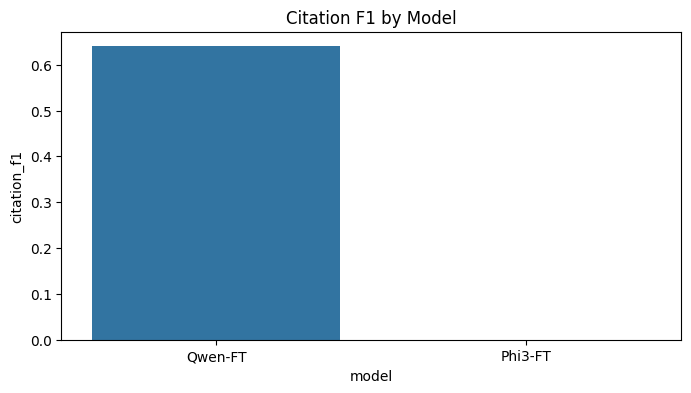

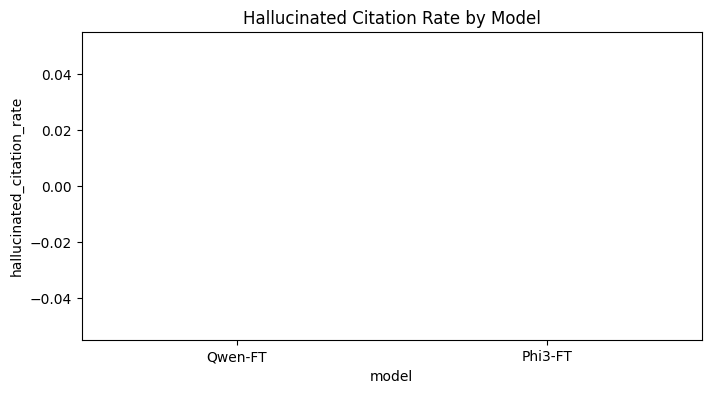

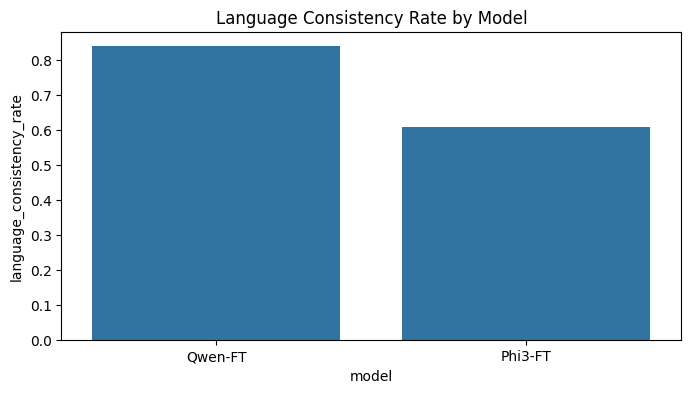

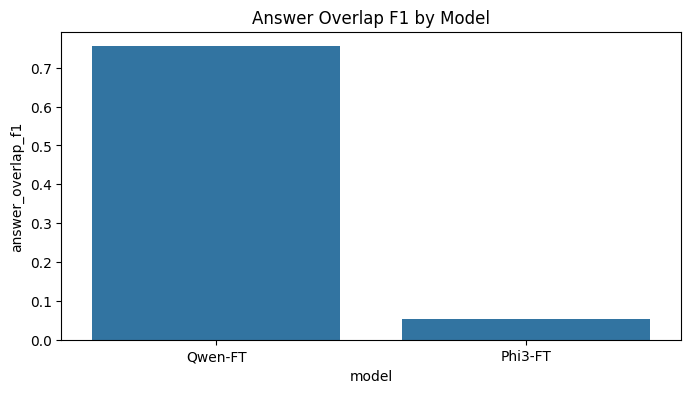

In [26]:
# Cell 21 — Visualization

plt.figure(figsize=(8, 4))
sns.barplot(data=wednesday_table, x="model", y="citation_f1")
plt.title("Citation F1 by Model")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=wednesday_table, x="model", y="hallucinated_citation_rate")
plt.title("Hallucinated Citation Rate by Model")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=wednesday_table, x="model", y="language_consistency_rate")
plt.title("Language Consistency Rate by Model")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=wednesday_table, x="model", y="answer_overlap_f1")
plt.title("Answer Overlap F1 by Model")
plt.show()

In [27]:
# Cell 22 — Save outputs

comparison_csv = OUTPUT_DIR / "wednesday_llm_comparison.csv"
detail_csv = OUTPUT_DIR / "model_eval_details.csv"

wednesday_table.to_csv(comparison_csv, index=False)
metrics_df.to_csv(detail_csv, index=False)

print("Saved:", comparison_csv)
print("Saved:", detail_csv)

Saved: /kaggle/working/llm_outputs/wednesday_llm_comparison.csv
Saved: /kaggle/working/llm_outputs/model_eval_details.csv


In [28]:
# Cell 23 — Quick spoken summary

best_citation = wednesday_table.sort_values("citation_f1", ascending=False).iloc[0]
best_language = wednesday_table.sort_values("language_consistency_rate", ascending=False).iloc[0]
lowest_hall = wednesday_table.sort_values("hallucinated_citation_rate", ascending=True).iloc[0]

print("Wednesday Update Summary")
print("=" * 60)
print(f"Best citation performance      : {best_citation['model']} ({best_citation['citation_f1']:.3f})")
print(f"Best language consistency     : {best_language['model']} ({best_language['language_consistency_rate']:.3f})")
print(f"Lowest hallucinated citations : {lowest_hall['model']} ({lowest_hall['hallucinated_citation_rate']:.3f})")
print("=" * 60)

Wednesday Update Summary
Best citation performance      : Qwen-FT (0.640)
Best language consistency     : Qwen-FT (0.840)
Lowest hallucinated citations : Qwen-FT (0.000)
